In [1]:
import math, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE="#e8a020"; BLUE="#6ab0f5"; GREEN="#4ade80"; RED="#f87171"
CYAN="#67e8f9";   PURPLE="#a78bfa"; GOLD="#fbbf24"; MUTED="#4a4d62"

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")

class FnLeaf(nn.Module):
    def __init__(self): super().__init__(); self.lin = nn.Linear(1, 1)
    def forward(self, x): return self.lin(x).squeeze(-1)
    def formula(self, _=None):
        w, b = self.lin.weight.item(), self.lin.bias.item()
        return f"({w:.6g}*x+{b:.6g})"

class EMLNode(nn.Module):
    def __init__(self, left, right): super().__init__(); self.left=left; self.right=right
    def forward(self, x=None):
        return torch.exp(self.left(x)) - torch.log(F.softplus(self.right(x)))
    def formula(self, _=None):
        return f"eml({self.left.formula()},{self.right.formula()})"

def build(s):
    if s == 'L': return FnLeaf()
    return EMLNode(build(s[1]), build(s[2]))

x_grid     = torch.linspace(0, 2*math.pi, 100)
x_in       = x_grid.unsqueeze(1)
sin_target = torch.sin(x_grid)
cos_target = torch.cos(x_grid)

# Previous ceilings from experiment_07
PREV = {'sin': 3.2143e-4, 'cos': 1.9124e-4}

print("Building blocks ready.")
print(f"Previous ceilings — sin: {PREV['sin']:.4e}  cos: {PREV['cos']:.4e}")


torch 2.11.0+cpu  |  device: cpu
Building blocks ready.
Previous ceilings — sin: 3.2143e-04  cos: 1.9124e-04


In [2]:
# ── Shapes: exp_07 winners ───────────────────────────────────────────────────
# B_e06_cos  (sin winner in exp_07): eml(eml(1,eml(1,1)),eml(eml(1,1),1))
SHAPE_B = ('N', ('N', 'L', ('N', 'L', 'L')), ('N', ('N', 'L', 'L'), 'L'))

# A_e04_sin  (cos winner in exp_07): eml(1,eml(eml(1,eml(1,1)),1))
SHAPE_A = ('N', 'L', ('N', ('N', 'L', ('N', 'L', 'L')), 'L'))

# C_e06_sin  (sin runner-up):        eml(eml(1,eml(1,1)),eml(1,eml(1,1)))
SHAPE_C = ('N', ('N', 'L', ('N', 'L', 'L')), ('N', 'L', ('N', 'L', 'L')))

# All cross-tested against both targets
SHAPES = {
    'B_e06_cos': SHAPE_B,
    'A_e04_sin': SHAPE_A,
    'C_e06_sin': SHAPE_C,
}

def _desc(s):
    if s=='L': return '1'
    return f"eml({_desc(s[1])},{_desc(s[2])})"

for name, s in SHAPES.items():
    print(f"  {name}: {_desc(s)}")


  B_e06_cos: eml(eml(1,eml(1,1)),eml(eml(1,1),1))
  A_e04_sin: eml(1,eml(eml(1,eml(1,1)),1))
  C_e06_sin: eml(eml(1,eml(1,1)),eml(1,eml(1,1)))


In [3]:
# ── Cosine-annealing ceiling attack ──────────────────────────────────────────

def ceiling_attack(shape, y_target, target_name,
                   lam=3e-5, num_restarts=20, steps=2000, lr_init=0.008):
    # 20 restarts x 2000 steps with CosineAnnealingLR.
    # Each restart also tries a warm restart (T_mult=2) to escape flat basins.
    best_loss, best_model = float('inf'), None
    losses = []

    for r in range(num_restarts):
        torch.manual_seed(r * 1013 + hash(target_name) % 991)
        model = build(shape)
        # Gaussian perturbation proportional to restart index
        with torch.no_grad():
            for p in model.parameters():
                p.add_(torch.randn_like(p) * (0.05 + 0.08 * (r % 5)))

        opt = torch.optim.Adam(model.parameters(), lr=lr_init, weight_decay=0)
        # Cosine annealing with warm restarts: T_0=400, T_mult=2
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            opt, T_0=400, T_mult=2, eta_min=1e-5)

        last = float('inf')
        for step in range(steps):
            opt.zero_grad()
            try:
                pred = model(x_in)
                raw  = F.mse_loss(pred, y_target)
                if not torch.isfinite(raw): break
                l1   = lam * sum(p.abs().sum()
                                 for nm, p in model.named_parameters()
                                 if 'weight' in nm)
                (raw + l1).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                scheduler.step()
                last = raw.item()
            except Exception: break
        losses.append(last)
        if last < best_loss:
            best_loss, best_model = last, model

    finite = [x for x in losses if x < 10]
    return dict(
        loss    = best_loss,
        formula = best_model.formula() if best_model else 'N/A',
        _model  = best_model,
        losses  = losses,
        finite_n = len(finite),
        spread   = max(finite) - min(finite) if finite else 0,
    )

print("ceiling_attack() ready.")
print(f"  20 restarts x 2000 steps x CosineAnnealingWarmRestarts(T0=400, Tmult=2)")


ceiling_attack() ready.
  20 restarts x 2000 steps x CosineAnnealingWarmRestarts(T0=400, Tmult=2)


In [4]:
# ── Run ──────────────────────────────────────────────────────────────────────

results = {}
t_start = time.time()
for target_name, y_target in [('sin', sin_target), ('cos', cos_target)]:
    results[target_name] = {}
    for shape_name, shape in SHAPES.items():
        t0  = time.time()
        rec = ceiling_attack(shape, y_target, target_name)
        elapsed = time.time() - t0
        beat = '★ NEW CEILING' if rec['loss'] < PREV[target_name] else ''
        print(f"{target_name}  {shape_name:<15}  MSE={rec['loss']:.4e}  "
              f"finite={rec['finite_n']}/20  spread={rec['spread']:.3e}  ({elapsed:.0f}s)  {beat}")
        results[target_name][shape_name] = rec

print(f"\nTotal: {time.time()-t_start:.0f}s")


sin  B_e06_cos        MSE=4.0251e-04  finite=17/20  spread=4.184e-02  (81s)  


sin  A_e04_sin        MSE=9.1597e-04  finite=16/20  spread=8.263e-02  (67s)  


sin  C_e06_sin        MSE=3.2285e-04  finite=18/20  spread=4.588e-02  (85s)  


cos  B_e06_cos        MSE=7.0515e-04  finite=14/20  spread=9.870e-02  (76s)  


cos  A_e04_sin        MSE=3.3024e-04  finite=17/20  spread=2.842e-02  (69s)  


cos  C_e06_sin        MSE=1.5897e-03  finite=14/20  spread=2.145e-02  (75s)  

Total: 453s



sin(x) results (prev ceiling: 3.2143e-04)
  1. C_e06_sin        3.2285e-04   
  2. B_e06_cos        4.0251e-04   
  3. A_e04_sin        9.1597e-04   

cos(x) results (prev ceiling: 1.9124e-04)
  1. A_e04_sin        3.3024e-04   
  2. B_e06_cos        7.0515e-04   
  3. C_e06_sin        1.5897e-03   


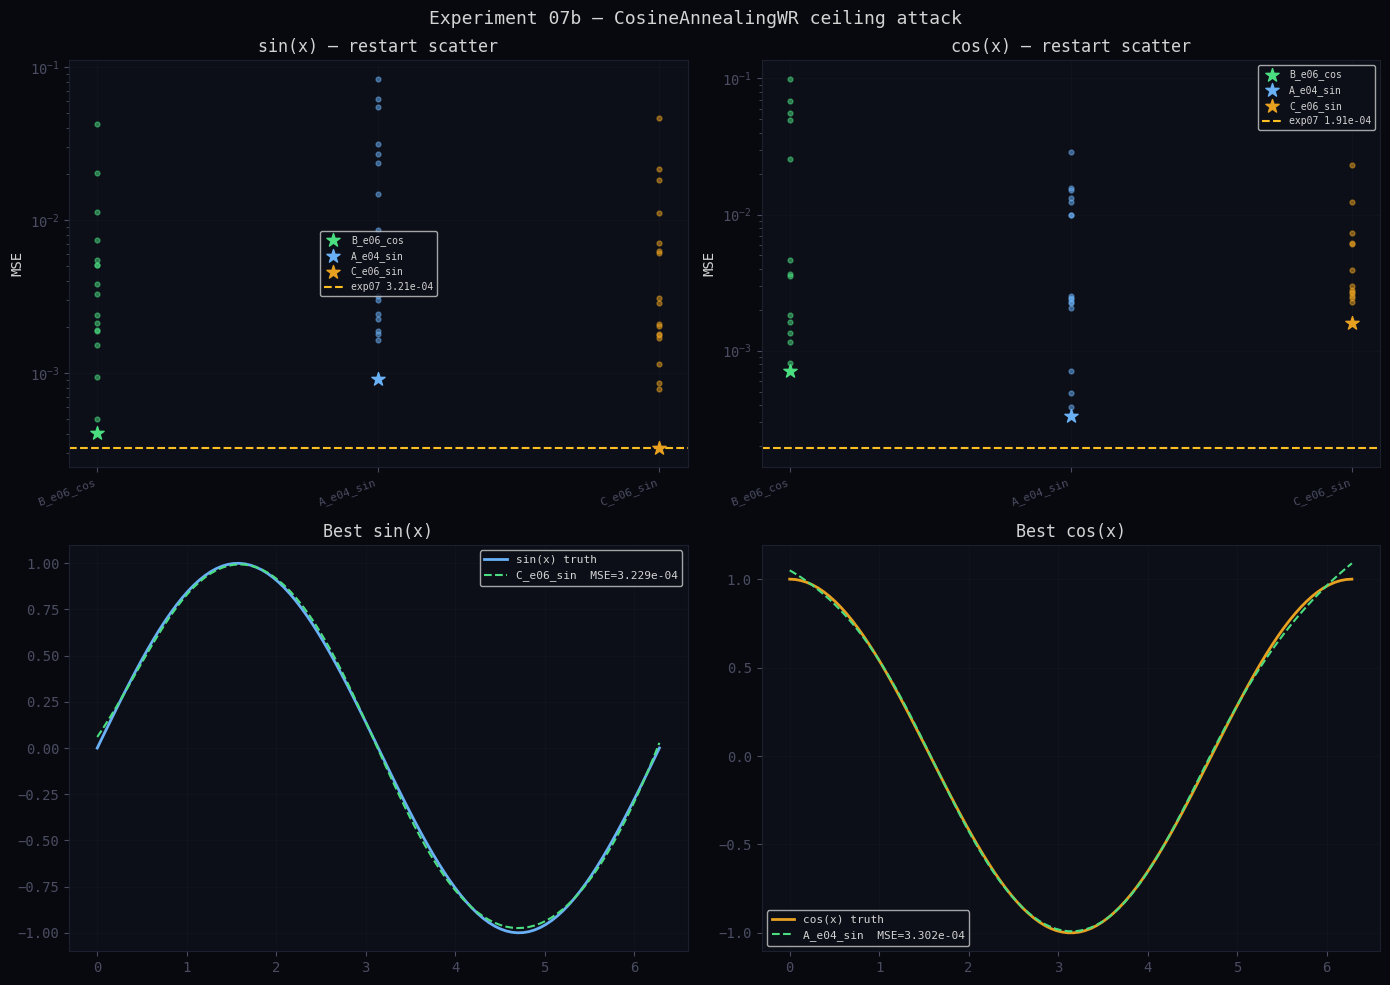


Saved -> D:\monogate\python\notebooks\experiment_07b_results.png


In [5]:
# ── Summary + plots ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 07b — CosineAnnealingWR ceiling attack', color='#d4d4d4', fontsize=13)

x_np   = x_grid.numpy()
colors = [GREEN, BLUE, ORANGE]

for col, (target_name, y_np, y_t) in enumerate([
        ('sin', torch.sin(x_grid).numpy(), sin_target),
        ('cos', torch.cos(x_grid).numpy(), cos_target)]):

    prev = PREV[target_name]
    ranked = sorted(results[target_name].items(), key=lambda kv: kv[1]['loss'])

    # Panel top: trial scatter (log scale)
    ax = axes[0, col]
    for i, (name, rec) in enumerate(results[target_name].items()):
        finite = [x for x in rec['losses'] if x < 10]
        ax.scatter([i]*len(finite), finite, alpha=0.5, s=12,
                   color=colors[i % len(colors)], zorder=3)
        ax.scatter([i], [rec['loss']], marker='*', s=100,
                   color=colors[i % len(colors)], zorder=5, label=name)
    ax.axhline(prev, color=GOLD, lw=1.5, ls='--', label=f"exp07 {prev:.2e}")
    ax.set_xticks(range(len(SHAPES)))
    ax.set_xticklabels(list(SHAPES.keys()), rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('MSE'); ax.set_yscale('log')
    ax.set_title(f'{target_name}(x) — restart scatter', color='#d4d4d4')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    # Panel bottom: best fit
    ax = axes[1, col]
    best_name, best_rec = ranked[0]
    c_truth = BLUE if col == 0 else ORANGE
    ax.plot(x_np, y_np, color=c_truth, lw=2, label=f'{target_name}(x) truth')
    with torch.no_grad():
        pred = best_rec['_model'](x_in).numpy()
    ax.plot(x_np, pred, color=GREEN, lw=1.5, ls='--',
            label=f"{best_name}  MSE={best_rec['loss']:.3e}")
    beat_str = ' ★' if best_rec['loss'] < prev else ''
    ax.set_title(f"Best {target_name}(x){beat_str}", color='#d4d4d4')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    print(f"\n{target_name}(x) results (prev ceiling: {prev:.4e})")
    for rank, (name, rec) in enumerate(ranked, 1):
        beat = '★' if rec['loss'] < prev else ' '
        print(f"  {rank}. {name:<15}  {rec['loss']:.4e}  {beat}")

plt.tight_layout()
out_png = Path('experiment_07b_results.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved -> {out_png.resolve()}")


In [6]:
# ── JSON export ──────────────────────────────────────────────────────────────

leaderboard = {}
for target_name in ('sin', 'cos'):
    ranked = sorted(results[target_name].items(), key=lambda kv: kv[1]['loss'])
    leaderboard[target_name] = [
        {'rank': i+1, 'name': n, 'mse': rec['loss'],
         'beats_prev': rec['loss'] < PREV[target_name],
         'formula': rec['formula']}
        for i, (n, rec) in enumerate(ranked)
    ]

out_json = Path('experiment_07b_results.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(leaderboard, f, indent=2, ensure_ascii=False)
print(f"Saved -> {out_json.resolve()}")

print()
print("EXPERIMENT 07b — CEILING ATTACK FINAL")
print("="*60)
for target_name in ('sin', 'cos'):
    best = leaderboard[target_name][0]
    prev = PREV[target_name]
    if best['beats_prev']:
        pct = (prev - best['mse']) / prev * 100
        print(f"  {target_name}: NEW CEILING {best['mse']:.4e}  (+{pct:.1f}%)  {best['name']}")
    else:
        print(f"  {target_name}: {best['mse']:.4e}  (exp07 {prev:.4e} still leads)  {best['name']}")


Saved -> D:\monogate\python\notebooks\experiment_07b_results.json

EXPERIMENT 07b — CEILING ATTACK FINAL
  sin: 3.2285e-04  (exp07 3.2143e-04 still leads)  C_e06_sin
  cos: 3.3024e-04  (exp07 1.9124e-04 still leads)  A_e04_sin
